# Final Project - What drives the price of a diamond?

**Student:** renejaci  
**Course:** 2586 (2026/P4) Python Programming for Business Intelligence, Hki & Vaasa  
**Repository:** https://github.com/renejaci/renejaci-PythonForBusinessInt2026/tree/main

## Table of contents

1. Introduction
2. How to use this notebook
3. Statement of AI use
4. Imports
5. Loading and exporting the raw data
6. Cleaning and transforming the data
7. Visual and quantitative analysis
8. Supervised machine learning - linear regression
9. Unsupervised machine learning - K-Means clustering
10. Connecting to the Gemini API for written insights
11. Exporting cleaned data and results
12. Data pipeline diagram
13. Conclusion

## 1. Introduction

### Context

Diamonds are graded and priced based on a few well-known attributes, with the main ones being the "four Cs": **carat** (weight), **cut** (quality of the cut), **color**, and **clarity**. The dataset also records the physical dimensions of each diamond in millimetres (`x` = length, `y` = width, `z` = depth), as well as two ratios that describe its proportions: `depth` (height relative to the average diameter, in %) and `table` (the flat top facet width relative to the widest point of the diamond).

For buyers and sellers, it's useful to understand which of these attributes actually influence the price, and whether there are types of diamonds in the data that appear to have better or worse value than others.

### Goal

The main question I aim to answer is:

> **Which physical and quality attributes of a diamond best explain its price, and can the attributes be used to group diamonds into similar "types"?**

To achieve this, the project will:

1. Load the *Diamonds* dataset (53,940 diamonds, 10 columns).
2. Clean and transform the data to make it suitable for analysis.
3. Explore the data visually and with summary statistics to see how each attribute relates to price.
4. Train a **linear regression** model to estimate how much each attribute contributes to the price (supervised machine learning).
5. Use **K-Means clustering** to group diamonds into types based on their attributes (unsupervised machine learning).
6. Use the **Gemini API** (an LLM) to generate short plain-English summaries of the regression and clustering results.

### Dataset

The *Diamonds* dataset was originally published in the `ggplot2` R package by Hadley Wickham. It also comes bundled with Python's `seaborn` library, which is how I load it in the notebook.

<!-- Source: https://ggplot2.tidyverse.org/reference/diamonds.html -->

## 2. How to use this notebook

### Folder structure

The notebook expects the following folder structure inside the repository:

- `project/`
    - `final_project.ipynb` - this notebook
    - `.env` - local file containing the Gemini API key (not in the repository)
    - `.gitignore` - set up to ignore `.env`
    - `data/`
        - `diamonds_raw.csv` - raw data, exported in Part 5
        - `diamonds_clean.csv` - cleaned data, exported in Part 11
        - `regression_results.csv` - regression coefficients and metrics
        - `cluster_summary.csv` - cluster centroids and sizes
        - `llm_insights.json` - cached Gemini responses, used as a fallback in Part 10

### Required packages

Anaconda already includes all the packages, except `python-dotenv`. Install it with `pip install python-dotenv`.

### Running the notebook

Run the cells in order from top to bottom. I checked that the whole notebook runs cleanly with **Kernel → Restart & Run All**.

### Gemini API key

Part 10 calls the Gemini API. To re-run that part with a live call, put a Gemini API key in a `.env` file in the `project/` folder, in the format `GEMINI_API_KEY=your_key_here`. Without a key, Part 10 falls back to the cached responses in `data/llm_insights.json` and the notebook still runs end-to-end.

### Reproducibility

`random_state=42` is used wherever there's randomness (train/test split, K-Means initialisation), so the results come out the same every time.

## 3. Statement of AI use

During this project I used AI tools in two ways:

1. **Claude (Anthropic)** for planning support and code-level help. I used it to talk through the structure of the project at the planning stage, and during the work I asked it to help me debug error messages, suggest cleaner variable names, and tighten up some of my pandas expressions. I read and ran every line of code myself before keeping it in the notebook.
2. **Grammarly** to clean up grammar and phrasing in the longer text sections.

The introduction, the commentary on the plots and the conclusion are written by me.

The Gemini API is also used inside the notebook in Part 10 as part of the actual analysis - it generates short written interpretations of the regression and clustering results based on prompts I wrote. This is a deliberate part of the analysis, not an undocumented use of AI to write the project.

## 4. Imports

All libraries used in the notebook are imported here in one place, making them easy to find. The `.env` file is also loaded here, so the Gemini API key is available later (in Part 10) without appearing in the code itself.

In [1]:
# General libraries
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loads the Gemini API key from the .env file (used in Part 10)
from dotenv import load_dotenv

# For making the API call to Gemini (used in Part 10)
import requests

# Scikit-learn - preprocessing
from sklearn.preprocessing import StandardScaler

# Scikit-learn - linear regression (Part 8)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Scikit-learn - K-Means clustering (Part 9)
from sklearn.cluster import KMeans

# Default seaborn theme so all plots look consistent
sns.set_theme(style="whitegrid")

# Fixed random state for reproducibility
RANDOM_STATE = 42

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Load the variables from .env into the environment
load_dotenv()

# Read the Gemini key into a variable. Used in Part 10.
gemini_api_key = os.environ.get("GEMINI_API_KEY")

# Quick sanity check - only print the first 4 characters so the key itself is never visible in the notebook output.
if gemini_api_key:
    print(f"Gemini key loaded: {gemini_api_key[:4]}...")
else:
    print("Gemini key NOT found. Check that .env is in the project folder "
          "and contains GEMINI_API_KEY=...")

Gemini key loaded: AIza...


## 5. Loading and exporting the raw data

I begin with loading the Diamonds dataset using seaborn's built-in functionality. The original data source is the `ggplot2` R package, which I referenced earlier (https://ggplot2.tidyverse.org/reference/diamonds.html).

The dataset contains 53,940 diamonds (rows) and 10 columns:

* `price` = sale price in US dollars (the variable I want to explain)
* `carat` = weight of the diamond
* `cut` = quality of the cut: Fair, Good, Very Good, Premium, Ideal
* `color` = diamond colour, from D (best) to J (worst)
* `clarity` = measurement of clarity, from I1 (worst) to IF (best)
* `depth` = total depth percentage
* `table` = width of the top of the diamond relative to its widest point
* `x`, `y`, `z` = length, width, and depth in millimetres

Once the dataset is loaded, I export it to `data/diamonds_raw.csv`. This keeps a local copy of the data and makes it easier to re-run the notebook later. The next cell contains a commented-out code block that can load the data from this local CSV instead of from seaborn, so the notebook can be re-run without an internet connection.

In [3]:
# Load the diamonds dataset from seaborn
diamonds_raw = sns.load_dataset("diamonds")

# Quick look at the shape and the first few rows
print("Shape:", diamonds_raw.shape)
diamonds_raw.head()

Shape: (53940, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
# Look at the data types and number of non-null values per column
diamonds_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [5]:
# Summary statistics for the numeric columns. 
# Useful for spotting weird values (e.g. x, y or z = 0, which can't happen for a real diamond)
diamonds_raw.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [6]:
# Save the raw DataFrame as a CSV in the data folder so the notebook can be re-run from the saved file
diamonds_raw.to_csv("data/diamonds_raw.csv", index=False)
print("Raw data exported to data/diamonds_raw.csv")

Raw data exported to data/diamonds_raw.csv


In [7]:
# Alternative loader: uncomment the lines below to load from the saved CSV instead of pulling from seaborn (e.g. if you don't have internet)

# diamonds_raw = pd.read_csv("data/diamonds_raw.csv")
# print("Raw data loaded from data/diamonds_raw.csv. Shape:", diamonds_raw.shape)

## 6. Cleaning and transforming the data

The `describe()` output from Part 5 already pointed at a few things to clean up before any analysis:

* The minimum values for `x`, `y`, and `z` are all zero. A real diamond can't have a dimension of zero, so those rows must be bad data.
* The maximum value for `y` is about 58 mm and for `z` about 31 mm, while `x` only goes up to about 11 mm. Since `x`, `y` and `z` are length, width, and depth of the same diamond (which should be roughly similar), the large `y` and `z` values look like outliers.
* The dataset may also have duplicate rows.

To deal with these, I work on a copy of the raw DataFrame so the original isn't changed. I drop the duplicates and the bad/outlier rows in `x`, `y`, `z`, and set an explicit order for the categorical columns (`cut`, `color`, `clarity`) so the label codes I assign later go from worst to best. I also add two new columns: `volume` (= `x * y * z`), which combines the three physical dimensions into one feature, and `price_per_carat`, which lets me compare diamonds of different sizes on a like-for-like basis.

In [8]:
# Work on a copy so the raw DataFrame stays untouched
diamonds = diamonds_raw.copy()

# Count duplicate rows
n_duplicates = diamonds.duplicated().sum()
print("Number of duplicate rows:", n_duplicates)

# Drop duplicate rows and reset the index
diamonds = diamonds.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicate rows:", diamonds.shape)

Number of duplicate rows: 146
Shape after dropping duplicate rows: (53794, 10)


In [9]:
# Count rows that have a zero in any of x, y, z
zero_mask = (diamonds["x"] == 0) | (diamonds["y"] == 0) | (diamonds["z"] == 0)
print("Number of rows with a zero in x, y or z:", zero_mask.sum())

# Drop those rows (since a real diamond can't have a side of 0 mm) and reset the index
diamonds = diamonds[~zero_mask].reset_index(drop=True)
print("Shape after dropping zero-dimension rows:", diamonds.shape)

Number of rows with a zero in x, y or z: 19
Shape after dropping zero-dimension rows: (53775, 10)


In [10]:
# y and z should be roughly the same size as x (a few mm up to ~11 mm).
# Anything way bigger than that is probably bad data, so I use 20 mm as a cut-off.
outlier_mask = (diamonds["y"] > 20) | (diamonds["z"] > 20)
print("Number of outlier rows in y or z (above 20 mm):", outlier_mask.sum())

# Drop those rows and reset the index
diamonds = diamonds[~outlier_mask].reset_index(drop=True)
print("Shape after dropping outliers:", diamonds.shape)

Number of outlier rows in y or z (above 20 mm): 3
Shape after dropping outliers: (53772, 10)


In [11]:
# Set the natural orderings (worst -> best) for each ordinal category
cut_order     = ["Fair", "Good", "Very Good", "Premium", "Ideal"]
color_order   = ["J", "I", "H", "G", "F", "E", "D"]    # J = worst, D = best
clarity_order = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]

diamonds["cut"]     = pd.Categorical(diamonds["cut"],     categories=cut_order,     ordered=True)
diamonds["color"]   = pd.Categorical(diamonds["color"],   categories=color_order,   ordered=True)
diamonds["clarity"] = pd.Categorical(diamonds["clarity"], categories=clarity_order, ordered=True)

# Check that it worked by printing the categories of each column
print("cut categories:    ", list(diamonds["cut"].cat.categories))
print("color categories:  ", list(diamonds["color"].cat.categories))
print("clarity categories:", list(diamonds["clarity"].cat.categories))

cut categories:     ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color categories:   ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity categories: ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']


In [12]:
# Volume in cubic millimetres
diamonds["volume"] = diamonds["x"] * diamonds["y"] * diamonds["z"]

# Price per carat (price normalised by weight)
diamonds["price_per_carat"] = diamonds["price"] / diamonds["carat"]

# Quick look at the cleaned DataFrame
print("Final cleaned shape:", diamonds.shape)
diamonds.head()

Final cleaned shape: (53772, 12)


,carat,cut,color,clarity,depth,table,price,x,y,z,volume,price_per_carat
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43,38.202030,1417.391304
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31,34.505856,1552.380952
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31,38.076885,1421.739130
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63,46.724580,1151.724138
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75,51.917250,1080.645161


In [13]:
# Sanity check: x, y, z should all have a positive min, no extreme max, and no missing values
print("Min of x, y, z:")
print(diamonds[["x", "y", "z"]].min())
print()
print("Max of x, y, z:")
print(diamonds[["x", "y", "z"]].max())
print()
print("Missing values per column:")
print(diamonds.isna().sum())

Min of x, y, z:
x    3.73
y    3.68
z    1.07
dtype: float64

Max of x, y, z:
x    10.74
y    10.54
z     6.98
dtype: float64

Missing values per column:
carat              0
cut                0
color              0
clarity            0
depth              0
table              0
price              0
x                  0
y                  0
z                  0
volume             0
price_per_carat    0
dtype: int64


## 7. Visual and quantitative analysis

Now that the data is clean, the next step is to look at how each attribute relates to the price of a diamond, both visually and with summary statistics. The findings will feed into the regression in Part 8 and the clustering in Part 9.

The analysis is organised into five short sub-sections:

- **7.1 Distribution of price** - what does the target variable look like?
- **7.2 Price by quality (the four Cs)** - how do `cut`, `color`, `clarity` and `carat` each affect price?
- **7.3 Numerical correlations with price** - which numeric features are most strongly related to price?
- **7.4 Combining carat and quality** - a closer look at how the four Cs interact.
- **7.5 Best- and worst-value diamonds** - which carat ranges deliver the highest price per carat?

### 7.1 Distribution of price

I start by looking at the variable I want to explain. The histogram below shows how prices are distributed across the dataset.

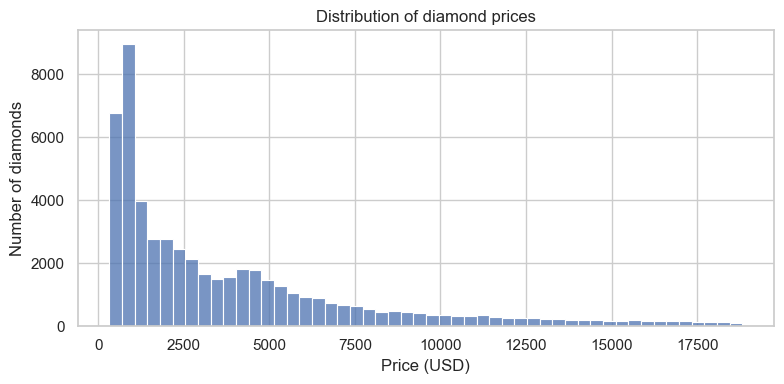

Summary statistics for price:
count    53772.00
mean      3931.14
std       3985.85
min        326.00
25%        951.00
50%       2401.00
75%       5324.00
max      18823.00
Name: price, dtype: float64


In [14]:
# Histogram of the price column
plt.figure(figsize=(8, 4))
sns.histplot(data=diamonds, x="price", bins=50)
plt.title("Distribution of diamond prices")
plt.xlabel("Price (USD)")
plt.ylabel("Number of diamonds")
plt.tight_layout()
plt.show()

# Summary statistics
print("Summary statistics for price:")
print(diamonds["price"].describe().round(2))

**Observation.** Most diamonds in the dataset cost under 5,000 USD, but there's a long tail of expensive ones going up to almost 19,000 USD. The mean (3,931 USD) is much higher than the median (2,401 USD), which confirms the distribution is right-skewed. Worth keeping in mind for the regression later, since a long tail like this can affect the model.

### 7.2 Price by quality (the four Cs)

Next, I look at how each of the four Cs (`carat`, `cut`, `color`, `clarity`) relates to price. For the categorical Cs I use boxplots so that I can see both the median price and the spread within each category. For `carat`, the only continuous one of the four, I use a scatter plot.

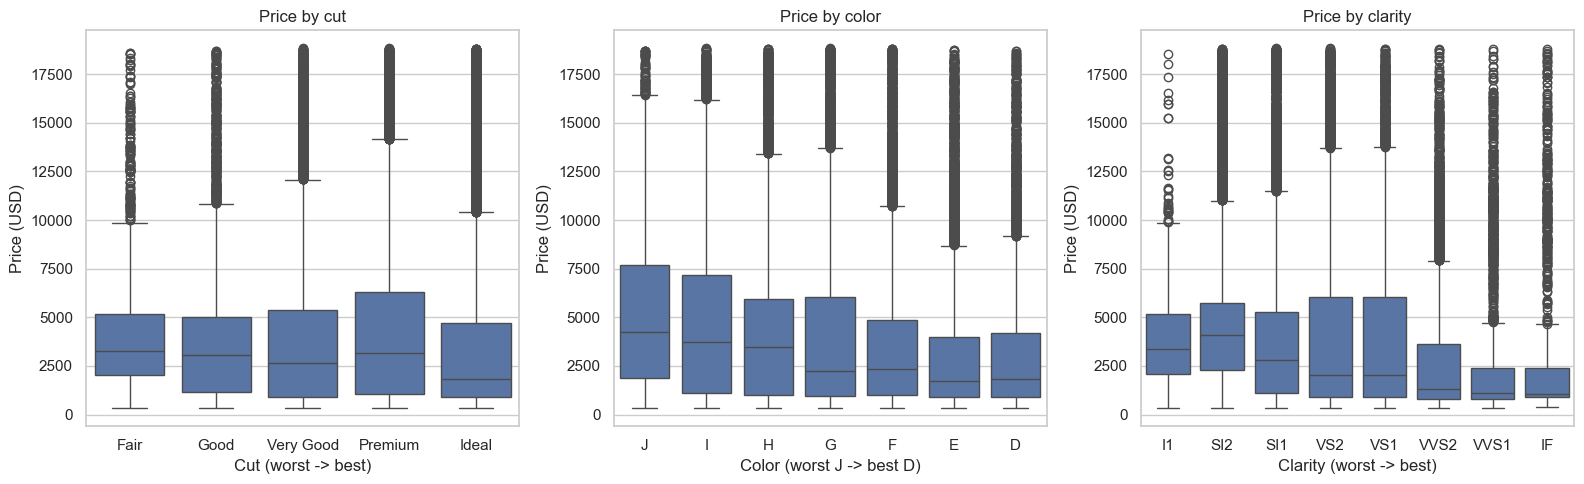

In [15]:
# Boxplots for the three categorical "Cs"
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(data=diamonds, x="cut", y="price", ax=axes[0])
axes[0].set_title("Price by cut")
axes[0].set_xlabel("Cut (worst -> best)")
axes[0].set_ylabel("Price (USD)")

sns.boxplot(data=diamonds, x="color", y="price", ax=axes[1])
axes[1].set_title("Price by color")
axes[1].set_xlabel("Color (worst J -> best D)")
axes[1].set_ylabel("Price (USD)")

sns.boxplot(data=diamonds, x="clarity", y="price", ax=axes[2])
axes[2].set_title("Price by clarity")
axes[2].set_xlabel("Clarity (worst -> best)")
axes[2].set_ylabel("Price (USD)")

plt.tight_layout()
plt.show()

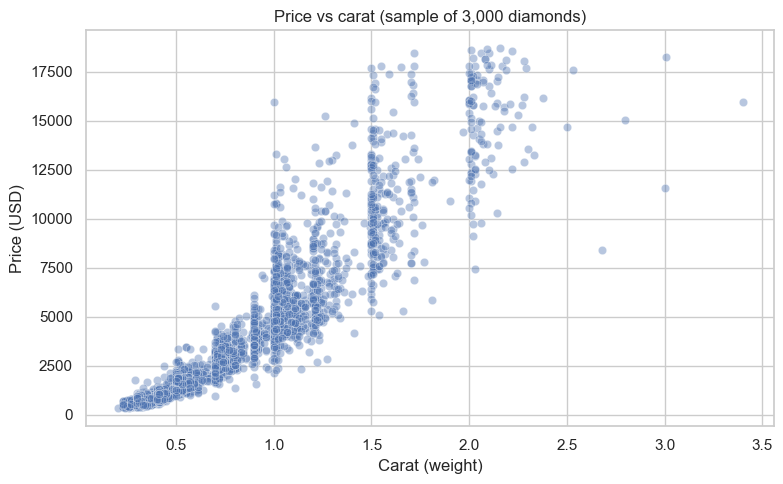

In [16]:
# Sample 3,000 rows so the plot doesn't get too cluttered
sample = diamonds.sample(3000, random_state=RANDOM_STATE)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=sample, x="carat", y="price", alpha=0.4)
plt.title("Price vs carat (sample of 3,000 diamonds)")
plt.xlabel("Carat (weight)")
plt.ylabel("Price (USD)")
plt.tight_layout()
plt.show()

**Observation.** Carat has a very obvious effect on price: heavier diamonds cost a lot more, and the curve looks more like a power curve than a straight line.

The categorical Cs are more confusing. The median prices for cut, color and clarity don't really go up with quality, in some cases (especially clarity) the median actually goes *down* as quality improves. I think this is happening because the highest-quality diamonds in the dataset also tend to be the smaller ones, and carat affects price so much that it overwhelms the quality effect in the boxplots. I'll come back to this with the regression in Part 8, since looking at one variable at a time isn't enough here.

### 7.3 Numerical correlations with price

To see how strongly each numeric attribute is related to price, I calculate the Pearson correlation matrix and plot it as a heatmap.

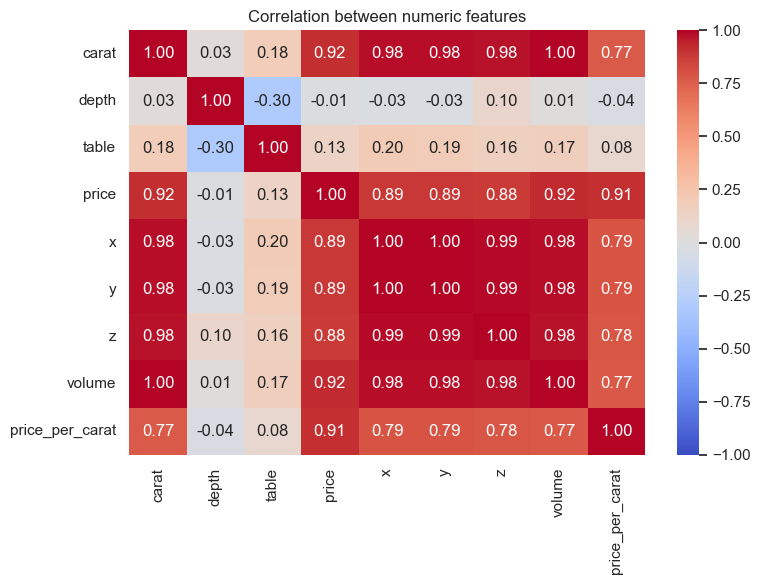

Correlation with price (sorted):
volume             0.923
carat              0.922
price_per_carat    0.913
y                  0.889
x                  0.887
z                  0.882
table              0.127
depth             -0.011
Name: price, dtype: float64


In [17]:
# Select numeric columns for the correlation matrix
numeric_cols = ["carat", "depth", "table", "price", "x", "y", "z",
                "volume", "price_per_carat"]
correlation = diamonds[numeric_cols].corr()

# Heatmap of the correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm",
            vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation between numeric features")
plt.tight_layout()
plt.show()

# Correlations with price, sorted from strongest to weakest
print("Correlation with price (sorted):")
print(correlation["price"].drop("price").sort_values(ascending=False).round(3))

**Observation.** Looking at the correlations, the numeric features fall into two groups:

- **Strongly correlated with price (about 0.88 and up):** carat, volume, x, y and z. That makes sense, since these are all really just measuring how big the diamond is.
- **Almost no linear correlation with price:** depth and table. These describe the *shape/proportions* of the diamond rather than its size, so it makes sense they don't move with price on their own.

The other thing I notice is that carat, volume, x, y and z are also highly correlated *with each other* (most of them above 0.97). They're basically measuring the same thing five different ways. Worth keeping in mind for the regression in Part 8: when features are this redundant, the individual coefficients can come out looking weird even if the model overall is fine.

### 7.4 Combining carat and quality

In Section 7.2 it looked like the categorical Cs didn't affect price the way I expected, probably because carat was getting in the way. To check this, I plot price vs carat again, this time coloured by `cut`, and put both axes on a log scale so the curve becomes roughly straight and easier to read.

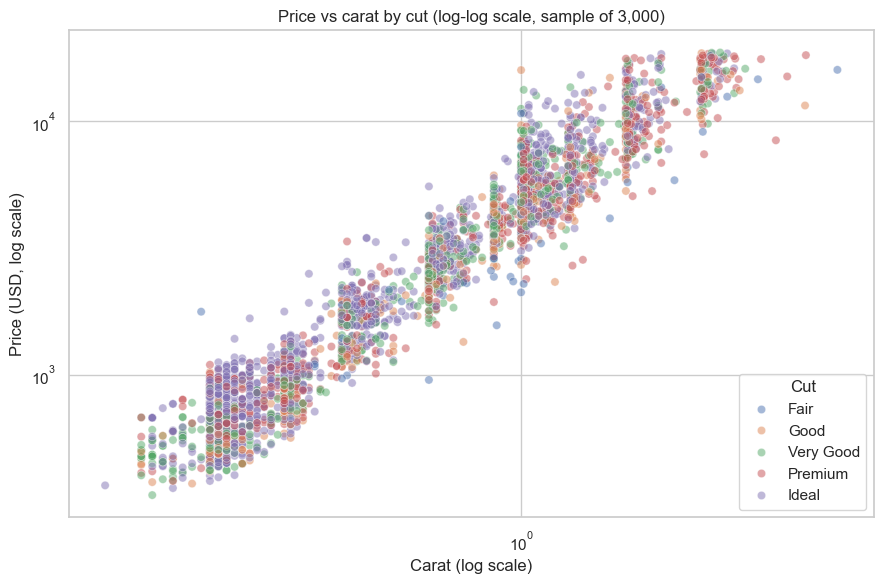

In [18]:
# Reusing the same sample as before
plt.figure(figsize=(9, 6))
sns.scatterplot(data=sample, x="carat", y="price",
                hue="cut", alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.title("Price vs carat by cut (log-log scale, sample of 3,000)")
plt.xlabel("Carat (log scale)")
plt.ylabel("Price (USD, log scale)")
plt.legend(title="Cut", loc="lower right")
plt.tight_layout()
plt.show()

**Observation.** Once you put both axes on a log scale, the relationship between carat and price looks almost linear, which means price scales roughly as a power of carat. The colours (cut) are pretty mixed up across the plot, so the effect of cut isn't dramatic, but if I look at a single vertical slice (carat roughly fixed) I can sort of see the Ideal and Premium points sitting a bit above the Fair and Good ones. So cut does seem to add a small premium for diamonds of the same size, even if it's hard to see clearly. This is the opposite of what the boxplots in 7.2 suggested, which is a good reminder that looking at one variable at a time can be misleading when other variables are correlated with it.

### 7.5 Best- and worst-value diamonds by carat range

To wrap up the analysis, I look at `price_per_carat` (the derived feature from Part 6) grouped into carat bins. This gives a feel for which size ranges have the highest price per carat - useful for the clustering analysis in Part 9.

Average price per carat by size range:
carat_bin
0–0.5      2336.0
0.5–1.0    3771.0
1.0–1.5    5641.0
1.5–2.0    6972.0
2.0–3.0    7045.0
3.0+       4518.0
Name: price_per_carat, dtype: float64


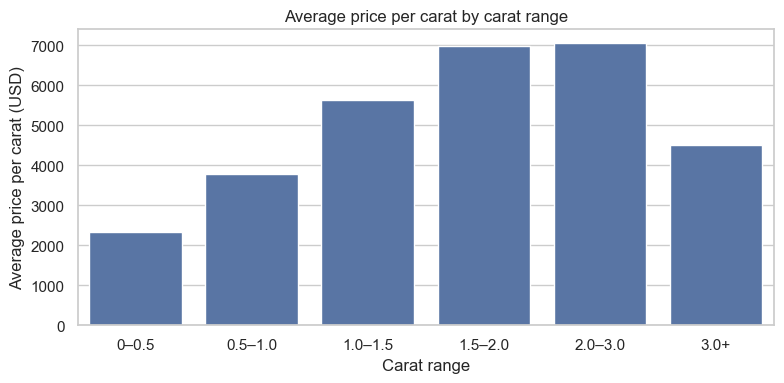

In [19]:
# Bin carat into ranges
bins   = [0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.5]
labels = ["0–0.5", "0.5–1.0", "1.0–1.5", "1.5–2.0", "2.0–3.0", "3.0+"]
diamonds["carat_bin"] = pd.cut(diamonds["carat"], bins=bins, labels=labels)

# Average price per carat in each bin
avg_price_per_carat = diamonds.groupby("carat_bin", observed=True)["price_per_carat"].mean()
print("Average price per carat by size range:")
print(avg_price_per_carat.round(0))

# Bar chart
plt.figure(figsize=(8, 4))
sns.barplot(x=avg_price_per_carat.index, y=avg_price_per_carat.values)
plt.title("Average price per carat by carat range")
plt.xlabel("Carat range")
plt.ylabel("Average price per carat (USD)")
plt.tight_layout()
plt.show()

**Observation.** Price per carat isn't constant across the size ranges. It climbs steeply, from about 2,300 USD per carat for the smallest diamonds (0-0.5 carat) up to around 7,000 USD per carat for diamonds in the 1.5-3 carat range. So bigger diamonds cost more for two reasons at once: there's more of them, and each carat is itself worth more. The 3.0+ bucket actually drops back down to about 4,500 USD per carat, but there are very few diamonds in that bin so I wouldn't read too much into it.

## 8. Supervised machine learning - linear regression

The goal of this section is to quantify how each attribute influences the price of a diamond. I chose a linear regression model for two main reasons:

1. The relationship between price and carat looked roughly linear on a log scale in Part 7, so a linear model is a reasonable first try.
2. The coefficients of a linear regression are directly interpretable - each one tells me how much price changes when that feature changes by one unit, with the others held fixed. Which is what I need for the question I'm trying to answer.

The steps below are:

1. Encode `cut`, `color` and `clarity` into numbers using their natural ordering.
2. Choose the feature set `X` and the target `y = price`.
3. Standardise the features so the coefficients are on a comparable scale.
4. Split into a training set and a test set (80 / 20).
5. Fit the regression on the training set.
6. Evaluate on the test set using MAE, RMSE and R².
7. Inspect the coefficients to identify which features have the strongest effect on price.

In [20]:
# Label-encode the three ordinal categorical columns
# Since I set the order in Part 6, the codes (0, 1, 2, ...) go from worst to best
diamonds_encoded = diamonds.copy()
diamonds_encoded["cut"]     = diamonds_encoded["cut"].cat.codes
diamonds_encoded["color"]   = diamonds_encoded["color"].cat.codes
diamonds_encoded["clarity"] = diamonds_encoded["clarity"].cat.codes

# Sanity check
print(diamonds_encoded[["cut", "color", "clarity"]].head())
print()
print("Unique codes per column:")
print("  cut:    ", sorted(diamonds_encoded["cut"].unique()))
print("  color:  ", sorted(diamonds_encoded["color"].unique()))
print("  clarity:", sorted(diamonds_encoded["clarity"].unique()))

   cut  color  clarity
0    4      5        1
1    3      5        2
2    1      5        4
3    3      1        3
4    1      0        1

Unique codes per column:
  cut:     [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4)]
  color:   [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5), np.int8(6)]
  clarity: [np.int8(0), np.int8(1), np.int8(2), np.int8(3), np.int8(4), np.int8(5), np.int8(6), np.int8(7)]


In [21]:
# Choose the features (X) and the target (y).
# I exclude:
#   - "price" (it is the target)
#   - "price_per_carat" (it is calculated from price, so it would leak the answer into the features)
#   - "carat_bin" (a helper column from Part 7 that is not needed here)
# I keep "volume" because it summarises x, y and z but is still a real input feature.
feature_cols = ["carat", "cut", "color", "clarity", "depth", "table",
                "x", "y", "z", "volume"]
X = diamonds_encoded[feature_cols]
y = diamonds_encoded["price"]

print("Features used:", feature_cols)
print("X shape:", X.shape)
print("y shape:", y.shape)

Features used: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z', 'volume']
X shape: (53772, 10)
y shape: (53772,)


In [22]:
# Standardise so all features have mean 0 and std 1, making the coefficients comparable
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# StandardScaler returns a NumPy array, so I wrap it back into a DataFrame to keep the column names
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols, index=X.index)
X_scaled.head()

,carat,cut,color,clarity,depth,table,x,y,z,volume
0,-1.199470,0.981788,0.936813,-1.246330,-0.173672,-1.100603,-1.592697,-1.578984,-1.605247,-1.199266
1,-1.241741,0.085812,0.936813,-0.639066,-1.362805,1.586075,-1.646336,-1.705055,-1.778892,-1.247671
2,-1.199470,-1.706141,0.936813,0.575462,-3.391326,3.377194,-1.503297,-1.497939,-1.778892,-1.200905
3,-1.072660,0.085812,-1.414380,-0.031802,0.455869,0.242736,-1.369199,-1.353858,-1.315837,-1.087655
4,-1.030389,-1.706141,-2.002178,-1.246330,1.085410,0.242736,-1.244040,-1.245798,-1.142191,-1.019653


In [23]:
# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training set:", X_train.shape[0], "rows")
print("Test set:    ", X_test.shape[0], "rows")

Training set: 43017 rows
Test set:     10755 rows


In [24]:
# Train the linear regression on the training data
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained.")
print("Intercept:", round(model.intercept_, 2))

Model trained.
Intercept: 3936.94


In [25]:
# Predictions on the unseen test data
y_pred = model.predict(X_test)

# Calculate the regression metrics
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("Test-set performance:")
print(f"  MAE  (mean absolute error):     ${mae:,.0f}")
print(f"  RMSE (root mean squared error): ${rmse:,.0f}")
print(f"  R^2  (coefficient of det.):     {r2:.3f}")

Test-set performance:
  MAE  (mean absolute error):     $785
  RMSE (root mean squared error): $1,207
  R^2  (coefficient of det.):     0.906


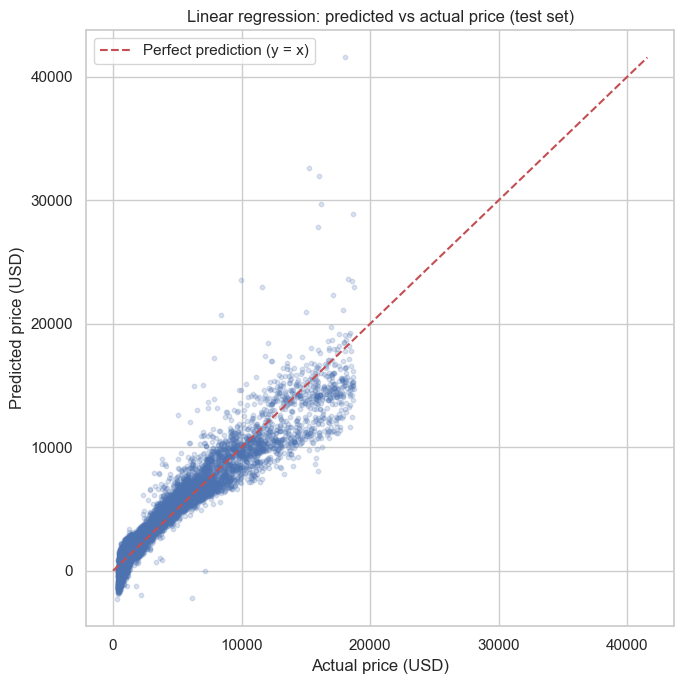

In [26]:
# Predicted vs actual prices on the test set.
# A perfect model would put all points on the dashed diagonal.
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.2, s=10)

# Reference line y = x
lims = [0, max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction (y = x)")

plt.title("Linear regression: predicted vs actual price (test set)")
plt.xlabel("Actual price (USD)")
plt.ylabel("Predicted price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

Standardised regression coefficients (sorted by impact):
   feature  coefficient
0   volume      4404.48
1        y      2355.13
2        z     -2096.09
3        x     -1591.03
4    carat      1039.72
5  clarity       812.51
6    color       557.97
7    depth       225.30
8      cut       133.26
9    table        20.50


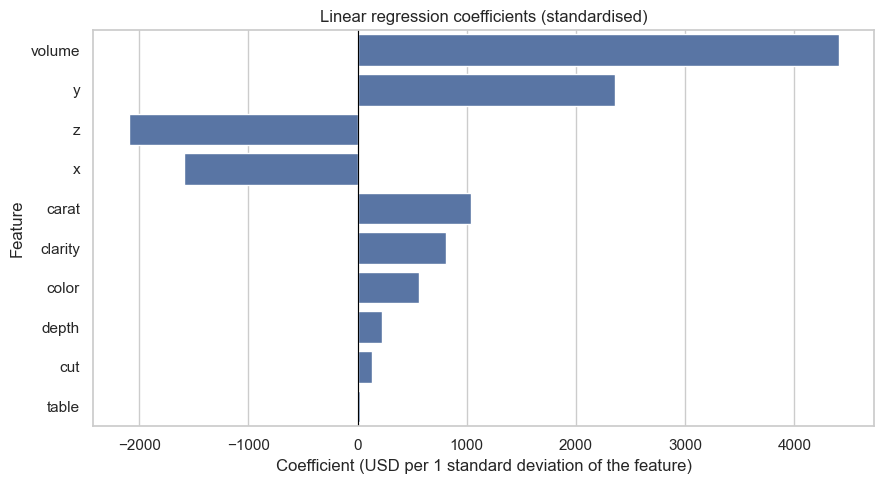

In [27]:
# Each coefficient = how many USD the price changes when the feature moves by one standard deviation
coefficients = pd.DataFrame({
    "feature":     feature_cols,
    "coefficient": model.coef_
})

# Sort by absolute size so the most influential features come first
coefficients["abs_coef"] = coefficients["coefficient"].abs()
coefficients = coefficients.sort_values("abs_coef", ascending=False).drop(columns="abs_coef")
coefficients = coefficients.reset_index(drop=True)

print("Standardised regression coefficients (sorted by impact):")
print(coefficients.round(2))

# Bar chart
plt.figure(figsize=(9, 5))
sns.barplot(data=coefficients, x="coefficient", y="feature")
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Linear regression coefficients (standardised)")
plt.xlabel("Coefficient (USD per 1 standard deviation of the feature)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Findings from the linear regression.**

- The model gets an R² of about 0.91 on the test set, so roughly 91% of the variation in price is explained by the ten features. The mean absolute error is about 785 USD against an average price of around 3,930 USD, so on average the model is off by about a fifth of the price. Not perfect, but pretty good for a simple linear model.
- The biggest coefficients in absolute terms are `volume`, `y`, `z` and `x`, but they come with mixed signs (volume is strongly positive, while x and z are strongly negative). This looked weird to me at first, but it's the same issue as in Part 7.3: these four features are basically all measuring the same thing (how big the diamond is) and they're correlated with each other above 0.97. When features are this correlated the regression can split the effect between them in strange ways. The way I read it is to ignore the individual signs and just look at the size features as a group - together they push the price up a lot when the diamond is bigger.
- After the size features, the next biggest drivers are the quality Cs, in the order **clarity > color > cut**. Better quality on any of these makes the price go up, which is what I'd expect.
- `depth` and `table` (the two proportion features) have very small coefficients, which fits with how weakly they correlated with price in Part 7.3.
- The predicted-vs-actual plot shows the model does well in the middle of the price range but tends to underpredict the most expensive diamonds. That makes sense given how skewed the price distribution was in Part 7.1, meaning there just aren't that many really expensive diamonds for the model to learn from.

In [28]:
# Build a small results DataFrame with the coefficients and metrics. Exported in Part 11.
regression_results = coefficients.copy()
regression_results["metric"] = ""        # blank for the coefficient rows
regression_results["value"]  = ""

# Add three extra rows for the metrics
metrics_rows = pd.DataFrame({
    "feature":     ["", "", ""],
    "coefficient": ["", "", ""],
    "metric":      ["MAE", "RMSE", "R2"],
    "value":       [round(mae, 2), round(rmse, 2), round(r2, 4)]
})
regression_results = pd.concat([regression_results, metrics_rows],
                               ignore_index=True)

regression_results

,feature,coefficient,metric,value
0,volume,4404.47646,,
1,y,2355.129934,,
2,z,-2096.091442,,
3,x,-1591.025318,,
4,carat,1039.724726,,
5,clarity,812.514877,,
6,color,557.972589,,
7,depth,225.301297,,
8,cut,133.259524,,
9,table,20.499535,,


## 9. Unsupervised machine learning - K-Means clustering

The regression in Part 8 showed which attributes have the biggest impact on price. The next question worth asking is whether there are natural *groups* of diamonds in the dataset that share similar profiles - for example, whether there are clear clusters of "small everyday diamonds" vs "premium large diamonds".

I use K-Means to answer this. The steps are as follows:

1. Choose a small set of features (carat, the three quality Cs, and price). I leave out `x`, `y`, `z` and `volume` because they are almost perfectly correlated with `carat` (Part 7.3) and would just pull the clusters towards size again.
2. Standardise those features so they're all on the same scale (K-Means uses distances, so unstandardised features would let the largest one dominate).
3. Use the **elbow method** to pick a reasonable number of clusters.
4. Fit the final K-Means model with that number of clusters.
5. Look at the average values in each cluster to figure out what each one represents.
6. Plot the clusters on a price-vs-carat scatter to check visually that the groups make sense.

In [29]:
# Use only carat as the size feature, so the clusters aren't dominated by size variables
cluster_features = ["carat", "cut", "color", "clarity", "price"]
X_cluster = diamonds_encoded[cluster_features]

# Standardise the features
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

print("Shape of clustering input:", X_cluster_scaled.shape)

Shape of clustering input: (53772, 5)


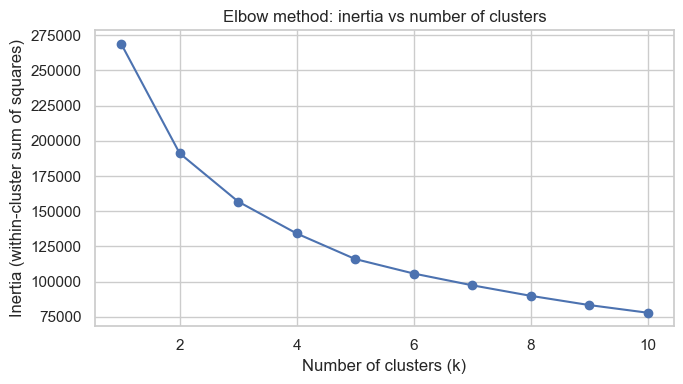

In [30]:
# Try k from 1 to 10 and record the inertia for each
inertias = []
k_values = range(1, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster_scaled)
    inertias.append(km.inertia_)

# Plot the elbow curve
plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow method: inertia vs number of clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster sum of squares)")
plt.tight_layout()
plt.show()

**Choice of k.** The curve flattens out around **k = 4**, meaning adding more clusters after that doesn't reduce the within-cluster spread much. So I'll use 4 clusters for the final model.

In [31]:
# Fit K-Means with the chosen number of clusters
N_CLUSTERS = 4
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_cluster_scaled)

# Add cluster labels back to the main DataFrame
diamonds["cluster"] = kmeans.labels_

# Cluster sizes
print(diamonds["cluster"].value_counts().sort_index())

cluster
0    12726
1    16754
2    11208
3    13084
Name: count, dtype: int64


In [32]:
# Average values per cluster
cluster_profile = diamonds.groupby("cluster")[
    ["carat", "price", "price_per_carat"]
].mean().round(2)

# Most common cut, color and clarity per cluster
cluster_profile["typical_cut"]     = diamonds.groupby("cluster")["cut"].agg(lambda s: s.mode()[0])
cluster_profile["typical_color"]   = diamonds.groupby("cluster")["color"].agg(lambda s: s.mode()[0])
cluster_profile["typical_clarity"] = diamonds.groupby("cluster")["clarity"].agg(lambda s: s.mode()[0])

# Cluster size
cluster_profile["size"] = diamonds["cluster"].value_counts().sort_index()

cluster_profile

,carat,price,price_per_carat,typical_cut,typical_color,typical_clarity,size
cluster,,,,,,,
0,0.43,1423.88,2992.70,Ideal,G,VVS2,12726
1,0.65,2461.35,3344.08,Ideal,E,SI1,16754
2,1.50,10158.15,6741.22,Premium,H,VS2,11208
3,0.74,2917.67,3509.05,Very Good,E,SI1,13084


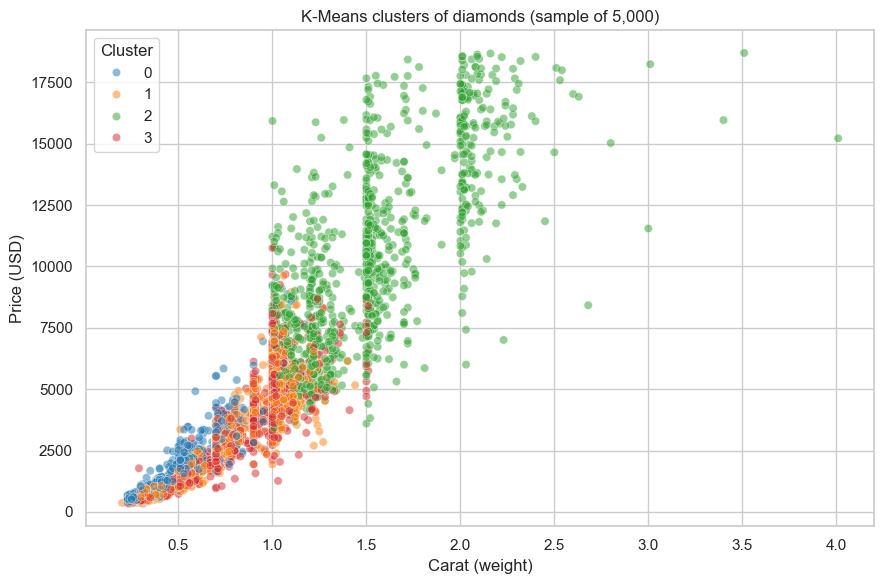

In [33]:
# Sample 5,000 rows so the scatter plot doesn't get too cluttered
plot_sample = diamonds.sample(5000, random_state=RANDOM_STATE)

plt.figure(figsize=(9, 6))
sns.scatterplot(data=plot_sample, x="carat", y="price",
                hue="cluster", palette="tab10", alpha=0.5)
plt.title("K-Means clusters of diamonds (sample of 5,000)")
plt.xlabel("Carat (weight)")
plt.ylabel("Price (USD)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

**Findings from the clustering.**

The four clusters split the dataset into four pretty different types of diamond. Going through them one by one:

- **Cluster 0: small but high-clarity stones.** Average carat 0.43 and average price around 1,400 USD, but the typical clarity is VVS2 (one of the best grades) and the typical cut is Ideal. So these are small diamonds with really good clarity - cheap on price but high on quality.
- **Cluster 1: small-to-medium, good colour, weaker clarity.** Average carat 0.65, average price about 2,500 USD. Typical colour is E (near the top of the colour scale) and cut is Ideal, but the typical clarity drops to SI1 (which is on the lower end). This is the biggest cluster (16,754 diamonds), so this seems to be the most common type of diamond in the dataset.
- **Cluster 2: large diamonds, mid-range quality.** Average carat 1.50 and average price about 10,200 USD, by far the most expensive group. The quality is actually only mid-range across the four Cs (Premium cut, H colour, VS2 clarity), so these aren't top-grade stones - it's mostly the size that drives the high price.
- **Cluster 3: medium-sized, mid-quality.** Average carat 0.74, average price about 2,900 USD. Lower cut and clarity than clusters 0 and 1, but good colour (E). Sits between the small high-clarity cluster 0 and the large cluster 2.

The price-vs-carat scatter shows the same thing visually: the four colours form bands at different price levels, with cluster 2 sitting well above the others. The clustering adds something the regression in Part 8 didn't: it shows the dataset isn't just one continuous cloud, but a few recognisable types of diamond, each making a different trade-off between size and quality.

In [34]:
# Inverse-transform the centroids back to original units
centroids_scaled = kmeans.cluster_centers_
centroids = pd.DataFrame(
    cluster_scaler.inverse_transform(centroids_scaled),
    columns=cluster_features
)
centroids.index.name = "cluster"

cluster_summary = centroids.round(2)
cluster_summary["size"] = diamonds["cluster"].value_counts().sort_index().values

cluster_summary

,carat,cut,color,clarity,price,size
cluster,,,,,,
0,0.43,3.38,3.13,5.12,1424.63,12726
1,0.65,3.59,4.10,2.20,2466.40,16754
2,1.50,3.00,2.39,2.79,10169.64,11208
3,0.74,1.47,3.65,2.36,2918.61,13084


## 10. Connecting to the Gemini API for written insights

In this section I use Google's Gemini API to turn the numerical results from Parts 8 and 9 into short written summaries. I send two prompts:

1. A prompt summarising the regression coefficients, asking for a short plain-English interpretation of which features matter most.
2. A prompt summarising the K-Means cluster profile, asking for a short description of what each cluster represents.

The Gemini responses are saved to `data/llm_insights.json` so the notebook still runs end-to-end without an API key. If no key is set, the saved responses are loaded from that file instead of calling the API.

In [35]:
# Prompt 1: ask Gemini to interpret the regression coefficients
regression_prompt = (
    "I trained a linear regression to predict the price of a diamond. "
    "Below are the standardised coefficients (USD per 1 standard deviation "
    "of each feature). Write a short plain-English interpretation in 3-4 "
    "sentences for a non-technical reader. Do not list the coefficients "
    "back to me, focus on what they mean.\n\n"
    f"{coefficients.round(2).to_string(index=False)}\n\n"
    f"The model achieved R^2 = {r2:.3f}, MAE = {mae:.0f} USD, "
    f"RMSE = {rmse:.0f} USD on the test set."
)

# Prompt 2: ask Gemini to describe the clusters
cluster_prompt = (
    "I ran a K-Means clustering on a diamond dataset with four clusters. "
    "Below is the average profile of each cluster (carat, the encoded "
    "quality categories cut/color/clarity where higher = better, and "
    "average price in USD). Write a short description (2-3 sentences "
    "per cluster) of what kind of diamond each cluster represents.\n\n"
    f"{cluster_summary.to_string()}"
)

print("Prompts ready.")

Prompts ready.


In [36]:
# Path where the Gemini responses are saved/loaded
INSIGHTS_PATH = "data/llm_insights.json"

# The Gemini API endpoint and headers (set up once so I can re-use them below)
URL = "https://generativelanguage.googleapis.com/v1beta/models/gemini-2.5-flash:generateContent"
HEADERS = {
    "Content-Type": "application/json",
    "x-goog-api-key": gemini_api_key
}

# Load any previously-saved responses from the JSON file
if os.path.exists(INSIGHTS_PATH):
    with open(INSIGHTS_PATH) as f:
        insights = json.load(f)
    print(f"Loaded {len(insights)} cached insights from {INSIGHTS_PATH}")
else:
    insights = {}
    print("No cached insights yet, will call the API.")

Loaded 2 cached insights from data/llm_insights.json


In [37]:
# Get the regression insight - either from the cache or by calling the API
if "regression" in insights:
    regression_insight = insights["regression"]
elif gemini_api_key:
    body = {"contents": [{"parts": [{"text": regression_prompt}]}]}
    response = requests.post(URL, headers=HEADERS, json=body)
    regression_insight = response.json()["candidates"][0]["content"]["parts"][0]["text"]
    insights["regression"] = regression_insight
else:
    regression_insight = None

if regression_insight:
    print(regression_insight)
else:
    print("No insight available - set GEMINI_API_KEY in .env or run once with a key to generate the cache.")

Our analysis shows how different characteristics of a diamond contribute to its price, with each feature evaluated on a comparable scale. The most significant factor is the diamond's overall volume, meaning larger diamonds, all else being equal, fetch a significantly higher price. While qualities like carat weight, clarity, and color also notably increase the price, some specific dimensions (like its 'z' and 'x' measurements) actually tend to lower it. Features such as the diamond's cut, depth, and table size have a much smaller influence on the final price, and overall, this model is quite accurate, typically predicting prices within about $785.


In [38]:
# Get the cluster insight the same way
if "clusters" in insights:
    cluster_insight = insights["clusters"]
elif gemini_api_key:
    body = {"contents": [{"parts": [{"text": cluster_prompt}]}]}
    response = requests.post(URL, headers=HEADERS, json=body)
    cluster_insight = response.json()["candidates"][0]["content"]["parts"][0]["text"]
    insights["clusters"] = cluster_insight
else:
    cluster_insight = None

if cluster_insight:
    print(cluster_insight)
else:
    print("No insight available - set GEMINI_API_KEY in .env or run once with a key to generate the cache.")

Here's a description of what kind of diamond each cluster represents:

**Cluster 0: The "High Quality, Small & Affordable" Diamond**
These are the smallest and most affordable diamonds in the dataset. Despite their low price and modest carat weight, they stand out for their exceptional clarity and good grades in cut and color. This cluster likely appeals to buyers seeking high visual purity and quality on a budget.

**Cluster 1: The "Balanced Brilliance" Diamond**
Representing the largest group of diamonds, this cluster offers a balance of moderate size and excellent visible quality. These medium-small diamonds boast the highest average cut and color grades, although they have the lowest clarity. This indicates a preference for external brilliance and desirable color, even with some internal imperfections.

**Cluster 2: The "Size-First Premium" Diamond**
This cluster contains the largest and most expensive diamonds by a significant margin. While their carat weight is substantial, their

In [39]:
# Save all insights to JSON so the notebook can run end-to-end without an API key next time
with open(INSIGHTS_PATH, "w") as f:
    json.dump(insights, f, indent=2, ensure_ascii=False)

print(f"Saved {len(insights)} insights to {INSIGHTS_PATH}")

Saved 2 insights to data/llm_insights.json


**Reflection.** The Gemini summaries line up well with what I observed in Parts 8 and 9, which is a good sign that the prompts gave the model enough context. The main use of the API here is to translate the numerical results - coefficients, cluster centroids - into a short paragraph that someone without a stats background could read. It's not replacing the analysis, just turning it into prose.

## 11. Exporting cleaned data and results

To wrap up the data pipeline, I export three more files into the `data/` folder:

- `diamonds_clean.csv` - the cleaned and transformed dataset from Part 6
- `regression_results.csv` - the regression coefficients and metrics from Part 8
- `cluster_summary.csv` - the cluster centroids and sizes from Part 9

Together with `diamonds_raw.csv` (exported in Part 5) and `llm_insights.json` (saved in Part 10), this gives a reviewer everything needed to inspect the input data, the cleaned data and every output of the analysis without having to re-run the notebook.

In [40]:
# Cleaned and transformed dataset
diamonds.to_csv("data/diamonds_clean.csv", index=False)
print("Saved data/diamonds_clean.csv")

# Regression coefficients and metrics
regression_results.to_csv("data/regression_results.csv", index=False)
print("Saved data/regression_results.csv")

# Cluster centroids and sizes (the index is the cluster number, so keep it)
cluster_summary.to_csv("data/cluster_summary.csv", index=True)
print("Saved data/cluster_summary.csv")

Saved data/diamonds_clean.csv
Saved data/regression_results.csv
Saved data/cluster_summary.csv


In [41]:
# Confirm all the data files are saved and have a sensible size
for filename in ["diamonds_raw.csv", "diamonds_clean.csv",
                 "regression_results.csv", "cluster_summary.csv",
                 "llm_insights.json"]:
    path = f"data/{filename}"
    if os.path.exists(path):
        size_kb = os.path.getsize(path) / 1024
        print(f"{path:40s} OK   ({size_kb:,.1f} KB)")
    else:
        print(f"{path:40s} MISSING")

data/diamonds_raw.csv                    OK   (2,564.3 KB)
data/diamonds_clean.csv                  OK   (4,737.9 KB)
data/regression_results.csv              OK   (0.3 KB)
data/cluster_summary.csv                 OK   (0.2 KB)
data/llm_insights.json                   OK   (2.2 KB)


## 12. Data pipeline diagram

The diagram below summarises the data pipeline for this project, from the original dataset through cleaning, analysis and machine learning to the exported files. It's intended as a quick overview for someone who doesn't want to read all the code.

![Data pipeline of the project](pipeline.png)

## 13. Conclusion

The main question of this project was: *Which physical and quality attributes of a diamond best explain its price, and can these attributes be used to categorize diamonds into similar "types"?*

The analysis provided answers to both questions.

**What drives the price of a diamond?**

The analysis showed that the most significant factor in predicting the price of a diamond is its size – measured by carat, volume, or its physical dimensions (x = length, y = width, and z = depth). These attributes were also discovered to be highly correlated (all had correlation coefficients above 0.97), which caused the linear regression to distribute the size effect among them with mixed signs. Nonetheless, overall, "size" remained the far most influential factor. After size, the most influential factor was the quality grades, in the order **clarity > color > cut**. A diamond's proportion features "depth" and "table" had minimal independent impact on price. The complete linear regression model explains about 91% of the variation in price (R² ≈ 0.91, MAE ≈ 785 USD on the test set).

**Are there natural groups of diamonds?**

The K-Means clustering with k = 4 found four distinct diamond types: a cluster of small but very high-clarity stones; a large group of small to medium sized diamonds with good color but lower clarity (the most common type in the dataset); a cluster of large, mid-quality stones (he most expensive group, where the size of the diamond was the main driver of the high price); and a cluster of medium-sized, mid-quality stones. The price-vs-carat plot showed the four groups as clear bands at different price levels.

**Unexpected observation/finding:**

One thing that surprised me was that the boxplots in Part 7.2 showed that the median price decreased as quality improved. While this initially felt counterintuitive, the regression analysis and the log-log scatter plot in Part 7.4 clarified this by showing that the highest-quality diamonds in the dataset tend to be smaller, leading to the carat (size) effect dominating the price even when quality is higher. Overall, this is a good reminder that looking at variables one at a time can be misleading when they are correlated.

**Limitations:**

The model is a basic linear regression without interaction terms or non-linear transformations. However, since the relationship between price and carat (size) seems to be non-linear (in Part 7.2 it looked closer to a power curve), a non-linear or log-transformed model would probably improve accuracy, especially for the most expensive diamonds, which this current model tends to underpredict. Additionally, it is worth noting that clustering results depend on the features chosen and the number of clusters, so the four "types" should be viewed as reasonable groupings rather than fixed, definitive categories.